# **Preparación de los Datos**
---

## **0. Integrantes del equipo de trabajo**
---

1. **Kevin Andres Leal Perez** (CC 1000519441)
2. **Dairo Enrique Morales Jimenez** (CC 1006656409)
3. **Sergio Andres Sierra Garcia** (CC 1010026343)

## **1. Carga de datos**
---

En esta fase se realiza la **carga y organización inicial** del dataset RealWaste desde Kaggle, preparando una estructura tabular con la ruta de cada imagen y su etiqueta. Esta estructura facilita el análisis y el procesamiento posterior al centralizar la información en un DataFrame.

- **Fuente de datos**: descarga automatizada con `kagglehub`.
- **Estructura esperada**: carpetas por clase dentro de `RealWaste`.
- **Salida clave**: tabla `df` con columnas `image_path` y `label`, base para la preparación de los datos.

In [1]:
#!pip install kagglehub

In [2]:
import os
import keras
import random
import warnings
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError

In [3]:
import pathlib

# Buscar la raíz del proyecto (contiene data.dvc) desde el directorio actual
_cwd = pathlib.Path().resolve()
_root = next(
    (p for p in [_cwd] + list(_cwd.parents) if (p / "realwaste.dvc").exists()),
    _cwd
)
path = str(_root / "realwaste")

# Construir DataFrame con rutas y etiquetas
records = []
for label in sorted(os.listdir(path)):
    label_dir = os.path.join(path, label)
    if os.path.isdir(label_dir):
        for filename in sorted(os.listdir(label_dir)):
            if filename.lower().endswith(".jpg"):
                records.append({"image_path": os.path.join(label_dir, filename), "label": label})

df = pd.DataFrame(records)
print("Path to dataset files:", path)
print(f"Dataset cargado: {len(df)} imágenes")

Path to dataset files: C:\Users\LENOVO\Documents\Metodologias_Agiles\Metodologias_Agiles_ML\realwaste
Dataset cargado: 4752 imágenes


## **2. Preparación y Limpieza de los Datos**
---

De manera ilustrativa, se realizará un **rebalanceo del conjunto de datos** de imágenes de residuos mediante sobremuestreo (*oversampling*) de las categorías minoritarias, es decir, aquellas que tienen menos de 700 imágenes.

### **2.1. Distribución de clases**

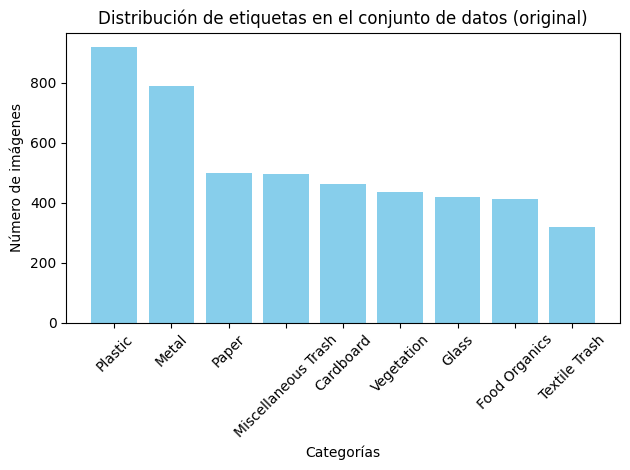

,image_path
label,
Plastic,921
Metal,790
Paper,500
Miscellaneous Trash,495
Cardboard,461
Vegetation,436
Glass,420
Food Organics,411
Textile Trash,318


In [4]:
variable_objetivo = 'label'

# Distribución de etiquetas
conteos = df.groupby(variable_objetivo).agg({'image_path': 'size'}).sort_values(by='image_path', ascending=False)

plt.bar(conteos.index, conteos['image_path'], color='skyblue')
plt.xlabel('Categorías')
plt.ylabel('Número de imágenes')
plt.title('Distribución de etiquetas en el conjunto de datos (original)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

conteos.style.background_gradient(cmap='Blues').set_caption("Distribución de etiquetas en el conjunto de datos")

### **2.2. Estrategia de rebalanceo**

Para evitar sobreajuste y lograr un mejor balance de las clases, el remuestreo **no se aplicará** a las dos clases más frecuentes (Plastic y Metal). Para todas las demás clases se busca alcanzar alrededor de **700 imágenes**, generando aproximadamente 1 859 imágenes nuevas.

La distribución de probabilidad de generación se ajusta entre las 7 clases restantes, asignando mayor probabilidad a las clases con menores conteos.

In [5]:
# Sobremuestreo hasta 700 imágenes por categoría
conteos_under700 = conteos[conteos['image_path'] < 700]
conteos_over700 = conteos[conteos['image_path'] >= 700]
n_aumentos = 700 * len(conteos_under700) + conteos_over700['image_path'].sum() - len(df)
print(f"Número de aumentos necesarios: {n_aumentos}")

# Distribución de probabilidades de cada categoría
diferencias = 700 - conteos['image_path']
diferencias = diferencias.clip(lower=0)
probabilidades = diferencias / diferencias.sum()
print("Probabilidades de aumento por categoría:")
print(probabilidades)

Número de aumentos necesarios: 1859
Probabilidades de aumento por categoría:
label
Plastic                0.000000
Metal                  0.000000
Paper                  0.107585
Miscellaneous Trash    0.110274
Cardboard              0.128564
Vegetation             0.142012
Glass                  0.150619
Food Organics          0.155460
Textile Trash          0.205487
Name: image_path, dtype: float64


### **2.3. Data Augmentation**

Se aplican transformaciones aleatorias a imágenes de las clases minoritarias para generar nuevas muestras. Cada imagen aumentada recibe **una única transformación aleatoria** de las disponibles:

- Brillo, contraste, saturación, matiz
- Rotación, traslación, zoom
- Flip horizontal/vertical
- Corte (*shear*)
- Ruido gaussiano

In [6]:
# Funciones de Keras para data augmentation (parámetros agresivos)
def apply_random_transforms(image: tf.Tensor, n_transforms: int = 3) -> tf.Tensor:
    """
    Aplica N transformaciones aleatorias encadenadas a la imagen.

    Args:
        image: Tensor (H, W, C), dtype float32, valores en [0, 1].
        n_transforms: número de transformaciones a encadenar.
    Returns:
        Tensor transformado de la misma forma.
    """
    transformations = [
        lambda img: keras.layers.RandomContrast(factor=0.6)(img[tf.newaxis])[0],
        lambda img: keras.layers.RandomSaturation(factor=(0.2, 2.5))(img[tf.newaxis])[0],
        lambda img: keras.layers.RandomHue(factor=0.25)(img[tf.newaxis])[0],
        lambda img: keras.layers.RandomRotation(factor=0.4)(img[tf.newaxis])[0],
        lambda img: keras.layers.RandomTranslation(height_factor=0.25, width_factor=0.25)(img[tf.newaxis])[0],
        lambda img: keras.layers.RandomZoom(height_factor=(-0.4, 0.4))(img[tf.newaxis])[0],
        lambda img: keras.layers.RandomFlip(mode="horizontal")(img[tf.newaxis])[0],
        lambda img: keras.layers.RandomFlip(mode="vertical")(img[tf.newaxis])[0],
        lambda img: keras.layers.RandomShear(x_factor=0.3, y_factor=0.3)(img[tf.newaxis])[0],
        lambda img: keras.layers.GaussianNoise(stddev=0.12)(img[tf.newaxis], training=True)[0],
    ]

    chosen = random.sample(transformations, k=n_transforms)
    result = image
    for t in chosen:
        result = t(result)
        result = tf.clip_by_value(result, 0.0, 1.0)
    return result

  0%|          | 0/1859 [00:00<?, ?it/s]

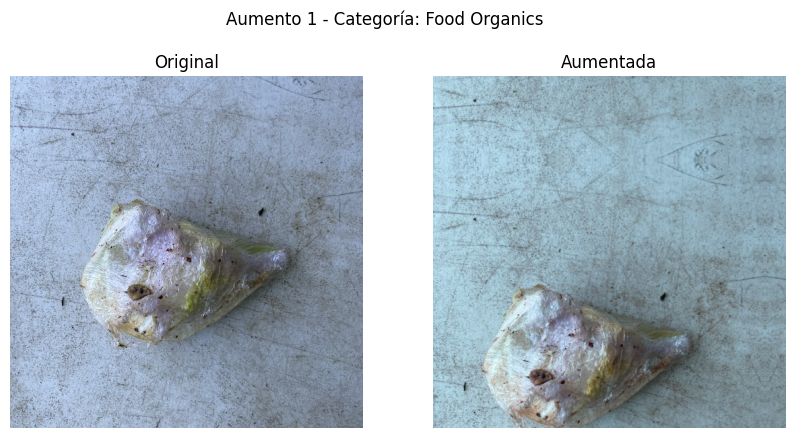

  0%|          | 1/1859 [00:00<23:47,  1.30it/s]

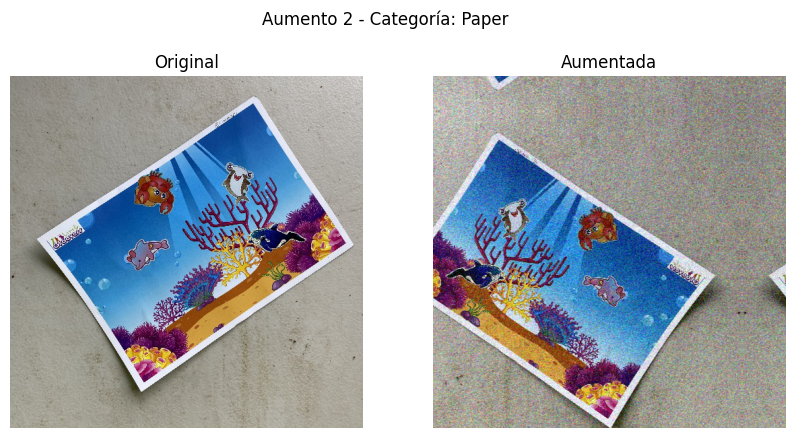

  0%|          | 2/1859 [00:01<17:03,  1.81it/s]

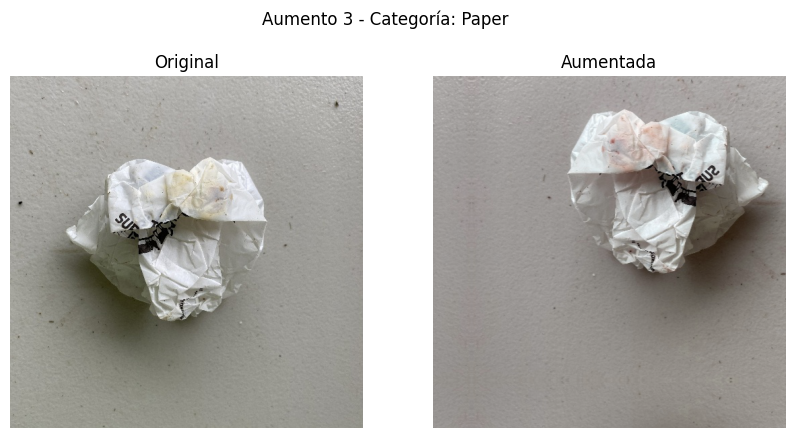

  0%|          | 3/1859 [00:01<19:18,  1.60it/s]

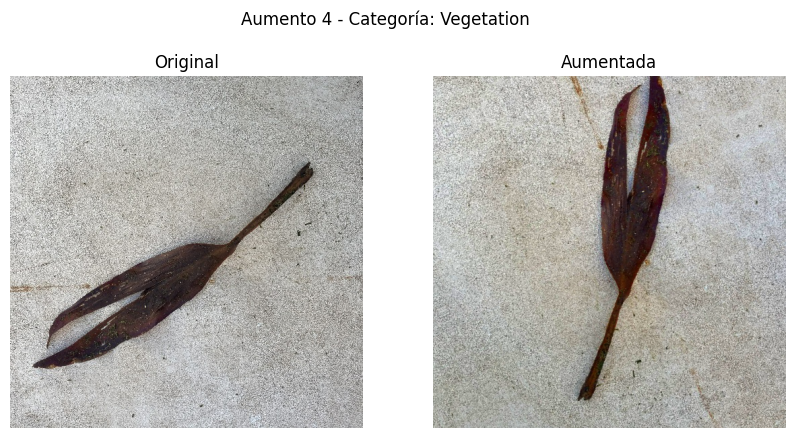

  0%|          | 4/1859 [00:02<17:07,  1.81it/s]

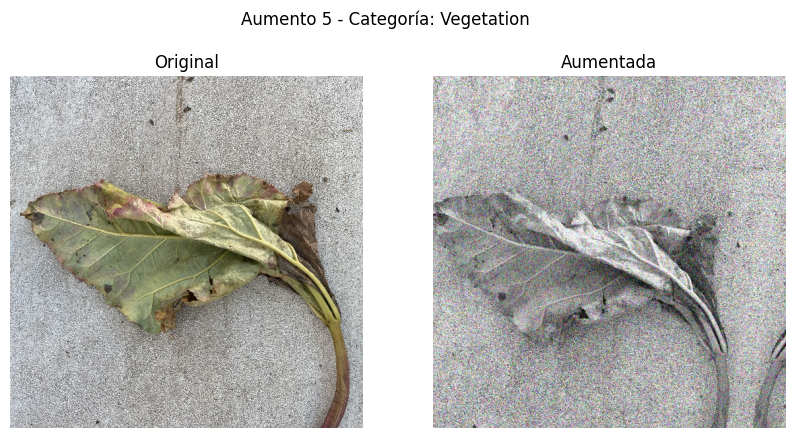

100%|██████████| 1859/1859 [04:18<00:00,  7.20it/s]

Imágenes aumentadas guardadas en: C:\Users\LENOVO\Documents\Metodologias_Agiles\Metodologias_Agiles_ML\realwaste


In [7]:
from tqdm import tqdm

# Carpeta donde se guardarán las imágenes aumentadas
augmented_dir = str(_root / "realwaste")
os.makedirs(augmented_dir, exist_ok=True)

df_augmented = df.copy()
for i in tqdm(range(n_aumentos)):
    category = np.random.choice(conteos.index, p=probabilidades)
    category_images = df[df[variable_objetivo] == category]["image_path"]
    base_img_path = np.random.choice(category_images)
    image_base = tf.convert_to_tensor(
        np.array(Image.open(base_img_path)) / 255.0, dtype=tf.float32
    )
    augmented_image = apply_random_transforms(image_base, n_transforms=3)

    # Guardar imagen aumentada en data/augmented/<clase>/
    cat_aug_dir = os.path.join(augmented_dir, category)
    os.makedirs(cat_aug_dir, exist_ok=True)
    new_filename = f"aug_{i}_{os.path.basename(base_img_path)}"
    new_image_path = os.path.join(cat_aug_dir, new_filename)
    aug_array = (augmented_image.numpy() * 255).clip(0, 255).astype(np.uint8)
    Image.fromarray(aug_array).save(new_image_path)

    # Visualización de las primeras 5 imágenes aumentadas
    if i < 5:
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))
        axes[0].imshow(image_base.numpy())
        axes[0].set_title("Original")
        axes[0].axis("off")
        axes[1].imshow(augmented_image.numpy())
        axes[1].set_title("Aumentada")
        axes[1].axis("off")
        plt.suptitle(f"Aumento {i+1} - Categoría: {category}")
        plt.show()

    df_augmented = pd.concat(
        [df_augmented, pd.DataFrame({"image_path": [new_image_path], "label": [category]})],
        ignore_index=True
    )

print(f"Imágenes aumentadas guardadas en: {augmented_dir}")

In [8]:
df_augmented.groupby(variable_objetivo).agg({'image_path': 'size'}).sort_values(by='image_path', ascending=False).style.background_gradient(cmap='Blues').set_caption("Distribución de etiquetas después del aumento")

,image_path
label,
Plastic,921
Metal,790
Food Organics,736
Miscellaneous Trash,705
Glass,704
Vegetation,698
Textile Trash,698
Paper,684
Cardboard,675


### **2.4. Redimensionamiento a 299×299 para InceptionV3**

Las imágenes originales tienen una resolución de **524×524 píxeles**. La arquitectura **InceptionV3** requiere entradas de **299×299 píxeles** con 3 canales de color (RGB). En este paso se redimensionan **todas** las imágenes del dataset aumentado (`df_augmented`) a dicha resolución y se almacenan en el directorio `realwaste_299/`, conservando la estructura de carpetas por clase.

- Se usa interpolación **Lanczos** (alta calidad) para el redimensionamiento.
- Las imágenes se guardan en formato **JPEG** con calidad 95.
- El resultado queda en `df_resized`, listo para el pipeline de entrenamiento.

In [9]:
from tqdm import tqdm

TARGET_SIZE = (299, 299)
resized_dir = str(_root / "realwaste_299")
os.makedirs(resized_dir, exist_ok=True)

records_resized = []
errors = 0

for _, row in tqdm(df_augmented.iterrows(), total=len(df_augmented), desc="Redimensionando"):
    src_path = row["image_path"]
    label = row["label"]
    cat_dir = os.path.join(resized_dir, label)
    os.makedirs(cat_dir, exist_ok=True)
    filename = os.path.basename(src_path)
    dest_path = os.path.join(cat_dir, filename)
    try:
        img = Image.open(src_path).convert("RGB").resize(TARGET_SIZE, Image.LANCZOS)
        img.save(dest_path, "JPEG", quality=95)
        records_resized.append({"image_path": dest_path, "label": label})
    except (OSError, UnidentifiedImageError) as e:
        warnings.warn(f"No se pudo procesar {src_path}: {e}")
        errors += 1

df_resized = pd.DataFrame(records_resized)
print(f"Imágenes redimensionadas: {len(df_resized)}  |  Errores: {errors}")
print(f"Resolución objetivo: {TARGET_SIZE[0]}×{TARGET_SIZE[1]} píxeles (3 canales RGB)")
print(f"Directorio de salida: {resized_dir}")


Redimensionando: 100%|██████████| 6611/6611 [03:11<00:00, 34.50it/s]

Imágenes redimensionadas: 6611  |  Errores: 0
Resolución objetivo: 299×299 píxeles (3 canales RGB)
Directorio de salida: C:\Users\LENOVO\Documents\Metodologias_Agiles\Metodologias_Agiles_ML\realwaste_299


In [10]:
df_resized.groupby(variable_objetivo).agg({'image_path': 'size'}).sort_values(by='image_path', ascending=False).style.background_gradient(cmap='Greens').set_caption("Distribución de etiquetas — dataset redimensionado 299×299")


,image_path
label,
Plastic,921
Metal,790
Food Organics,736
Miscellaneous Trash,705
Glass,704
Vegetation,698
Textile Trash,698
Paper,684
Cardboard,675


El **rebalanceo de categorías** se realizó mediante *data augmentation* dirigido a las clases con menos de 700 imágenes, aplicando transformaciones aleatorias para incrementar su representación sin depender de nuevas recolecciones. Esta estrategia reduce el sesgo hacia clases mayoritarias y mejora la capacidad del modelo para aprender patrones más equitativos entre etiquetas.

Como resultado, la distribución final por categoría queda más homogénea en `df_augmented`, lo que fortalece la etapa de entrenamiento y evaluación.

Posteriormente, la totalidad del dataset aumentado fue **redimensionada a 299×299 píxeles** (3 canales RGB) y almacenada en `realwaste_299/`. Esta resolución es el tamaño de entrada estándar de **InceptionV3**, por lo que `df_resized` es el artefacto de salida listo para el pipeline de entrenamiento.

## **3. Conclusiones**
---

En este cuaderno se ejecutó el pipeline de **preparación y limpieza** del dataset RealWaste, abordando el desbalance de clases identificado en la fase de entendimiento de los datos.

- Se identificaron **7 clases minoritarias** con menos de 700 imágenes; las 2 clases mayoritarias (Plastic y Metal) no se modificaron.
- Se generaron **1 859 imágenes artificiales** mediante transformaciones aleatorias aplicadas a imágenes existentes (*data augmentation*).
- El dataset resultante (`df_augmented`) presenta una distribución más homogénea, aproximando cada clase a 700 imágenes.
- Las transformaciones aplicadas (brillo, contraste, rotación, zoom, flip, ruido, entre otras) preservan la semántica de los residuos y aumentan la diversidad visual para mejorar la generalización del modelo.
- El dataset preparado queda listo para ser consumido por el pipeline de entrenamiento en `scripts/training/`.

# **Créditos**
---

* **Profesor:** [Fabio Augusto Gonzalez](https://dis.unal.edu.co/~fgonza/)
* **Asistentes docentes :**
  * [Santiago Toledo Cortés](https://sites.google.com/unal.edu.co/santiagotoledo-cortes/)
* **Diseño de imágenes:**
    - [Mario Andres Rodriguez Triana](https://www.linkedin.com/in/mario-andres-rodriguez-triana-394806145/).
* **Coordinador de virtualización:**
    - [Edder Hernández Forero](https://www.linkedin.com/in/edder-hernandez-forero-28aa8b207/).

**Universidad Nacional de Colombia** - *Facultad de Ingeniería*